# Mutual Fund Investment Trends in India

**Tools:** Python, Pandas, Matplotlib, NumPy

**Data Source:** AMFI India via Kaggle

**Author:** Utsav

**Program: PGDM-BM | Aspiring Business Analyst**  


This project analyses mutual fund schemes in India to understand investment trends, top AMCs, NAV patterns, and fund launch history.

**🏦 Business Problem**

"India's mutual fund industry has grown from ₹14 trillion to ₹82 trillion AUM in just 10 years — yet most retail investors lack clarity on which fund categories, AMCs, and scheme types offer the best value. This project analyses 14,000+ AMFI-registered schemes to identify investment patterns, AMC dominance, NAV trends, and fund accessibility for data-driven investment decision making."

## 📋 Research Hypotheses

H1 — Market Structure

"Open Ended schemes dominate the Indian MF market due to investor preference for liquidity and free entry/exit."

H2 — AMC Dominance

"Large private sector AMCs like ICICI Prudential lead the market by number of schemes, indicating aggressive product diversification strategy."

H3 — NAV Pattern

"Majority of Indian mutual fund schemes have NAV under ₹100, suggesting most funds are relatively young or recently launched."

H4 — Size vs Performance

"AMCs with fewer schemes have higher average NAV than large AMCs — proving that scheme count does not reflect fund performance."

H5 — Industry Growth

"Fund launches peaked around 2018 due to SEBI recategorisation and declined during COVID-19 (2020), followed by gradual recovery."



## Libraries

In [ ]:
!pip install plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# update path as per your setup
#dataset: https://www.kaggle.com/datasets/tharunreddy2911/mutual-fund-data
mutual_fund = '/content/drive/MyDrive/DataSet for practice/mutual_fund_data.csv'
df = pd.read_csv(mutual_fund)
df


,Scheme_Code,Scheme_Name,AMC,Scheme_Type,Scheme_Category,Scheme_NAV_Name,Scheme_Min_Amt,NAV,Latest_NAV_Date,Average_AUM_Cr,AAUM_Quarter,ISIN_Div_Payout/Growth,ISIN_Div_Reinvestment,ISIN_Div_Payout/Growth/Div_Reinvestment,Launch_Date,Closure_Date
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund - R...,5000,894.8900,2026-06-05,4428.2119,January - March 2026,INF209K01165,-,INF209K01165,1995-02-24,1995-02-24
1,100034,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund -Re...,5000,130.3300,2026-06-05,457.6450,January - March 2026,INF209K01157,INF209K01CE5,INF209K01157INF209K01CE5,1995-02-24,1995-02-24
2,100037,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Regular - ...,5000,12.9669,2026-06-05,11.1344,January - March 2026,INF209K01587,INF209K01CY3,INF209K01587INF209K01CY3,1994-01-01,1994-01-01
3,100038,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Growth - R...,5000,127.2745,2026-06-05,780.1475,January - March 2026,INF209K01579,-,INF209K01579,1994-01-01,1994-01-01
4,100039,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Birla Income Plus-Institutional (Growth),5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994-01-01,1994-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16222,154410,Tata Multi Sector Passive FOF,Tata Asset Management Limited,Open Ended,Other Scheme - FoF Domestic,Tata Multi Sector Passive FOF Direct Plan IDCW...,Rs 5000/- and in multiple of Re.1/- thereafter,NaN,NaN,NaN,NaN,NaN,NaN,INF277KA1EX2,2026-06-22,NaN
16223,154413,Choice Overnight Fund,Choice AMC Private Limited,Open Ended,Debt Scheme - Overnight Fund,Choice Overnight Fund - Growth Option - Direct...,Growth Rs 1000/- Daily IDCW Rs.10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01,NaN
16224,154414,Choice Overnight Fund,Choice AMC Private Limited,Open Ended,Debt Scheme - Overnight Fund,Choice Overnight Fund - Daily IDCW Option - Re...,Growth Rs 1000/- Daily IDCW Rs.10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01,NaN
16225,154415,Choice Overnight Fund,Choice AMC Private Limited,Open Ended,Debt Scheme - Overnight Fund,Choice Overnight Fund - Growth Option - Regula...,Growth Rs 1000/- Daily IDCW Rs.10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01,NaN


## Data Cleaning

In [ ]:
# checking for null values
df.isnull().sum() / len(df) * 100


,0
Scheme_Code,0.000000
Scheme_Name,0.000000
AMC,0.000000
Scheme_Type,0.000000
Scheme_Category,0.000000
Scheme_NAV_Name,0.000000
Scheme_Min_Amt,0.184877
NAV,12.399088
Latest_NAV_Date,12.399088
Average_AUM_Cr,49.460775


In [ ]:
# dropping columns with more than 49% missing values
df = df.drop(columns=['Closure_Date', 'Average_AUM_Cr', 'AAUM_Quarter', 'Latest_NAV_Date'], errors='ignore')
df.dropna(inplace=True)


In [ ]:
# filling missing ISIN values
df['ISIN_Div_Payout/Growth'] = df['ISIN_Div_Payout/Growth'].fillna('Unknown')
df['ISIN_Div_Reinvestment'] = df['ISIN_Div_Reinvestment'].fillna('Unknown')
df['ISIN_Div_Payout/Growth/Div_Reinvestment'] = df['ISIN_Div_Payout/Growth/Div_Reinvestment'].fillna('Unknown')


In [ ]:
# filling missing minimum amount with median
df['Scheme_Min_Amt'] = pd.to_numeric(df['Scheme_Min_Amt'], errors='coerce')
df['Scheme_Min_Amt'] = df['Scheme_Min_Amt'].fillna(df['Scheme_Min_Amt'].median())


In [ ]:
# converting launch date to datetime
df['Launch_Date'] = pd.to_datetime(df['Launch_Date'], errors='coerce')
df.dropna(subset=['Launch_Date'], inplace=True)


In [ ]:
# checking shape of dataset
df.shape


(14029, 12)

In [ ]:
# checking info in dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 14029 entries, 0 to 16214
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Scheme_Code                              14029 non-null  int64         
 1   Scheme_Name                              14029 non-null  object        
 2   AMC                                      14029 non-null  object        
 3   Scheme_Type                              14029 non-null  object        
 4   Scheme_Category                          14029 non-null  object        
 5   Scheme_NAV_Name                          14029 non-null  object        
 6   Scheme_Min_Amt                           14029 non-null  float64       
 7   NAV                                      14029 non-null  float64       
 8   ISIN_Div_Payout/Growth                   14029 non-null  object        
 9   ISIN_Div_Reinvestment                    140

In [35]:
# Finding unique values
df['AMC'].nunique()


51

In [36]:
# Finding unique values
df['Scheme_Category'].nunique()

46

## Analysis 1 — Scheme Type Distribution

Checking how many types of schemes exist in the dataset and what percentage each type holds.


In [ ]:
df['Scheme_Type'].nunique()


3

In [ ]:
df['Scheme_Type'].value_counts()


,count
Scheme_Type,
Open Ended,9252
Close Ended,4736
Interval Fund,41


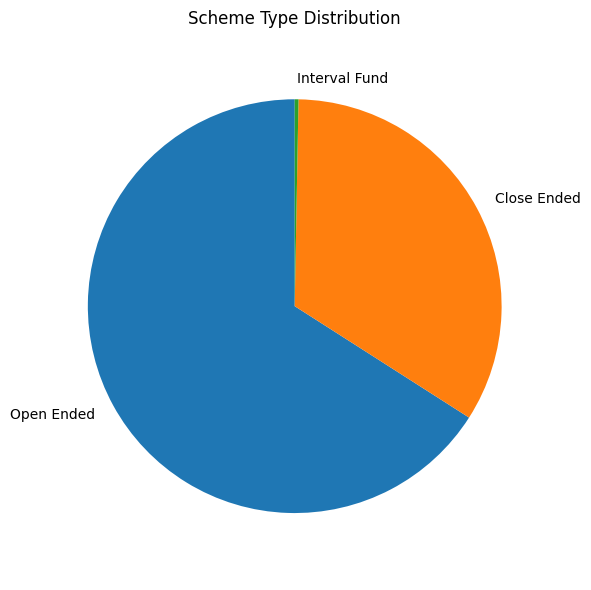

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(df['Scheme_Type'].value_counts(), labels=df['Scheme_Type'].value_counts().index, startangle=90)
plt.title('Scheme Type Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()


**Insight:** Open Ended schemes dominate at ~66%, reflecting investor preference for liquidity. Close Ended funds are at ~34% and Interval Funds are negligible at 0.3%.


## Analysis 2 — Top 10 AMCs by Number of Schemes

Identifying which fund houses offer the most schemes in the market.


In [ ]:
top_amc = df['AMC'].value_counts().head(10)
top_amc


,count
AMC,
ICICI Prudential Asset Management Company Limited,2490
Nippon Life India Asset Management Limited,1867
UTI Asset Mgmt. Co. Ltd.,1335
Kotak Mahindra Asset Management Company Limited.,886
HDFC Asset Management Company Limited,541
SBI Funds Management Limited,529
Aditya Birla Sun Life AMC Limited,477
Bandhan AMC Limited,431
Axis Asset Management Co. Ltd.,410


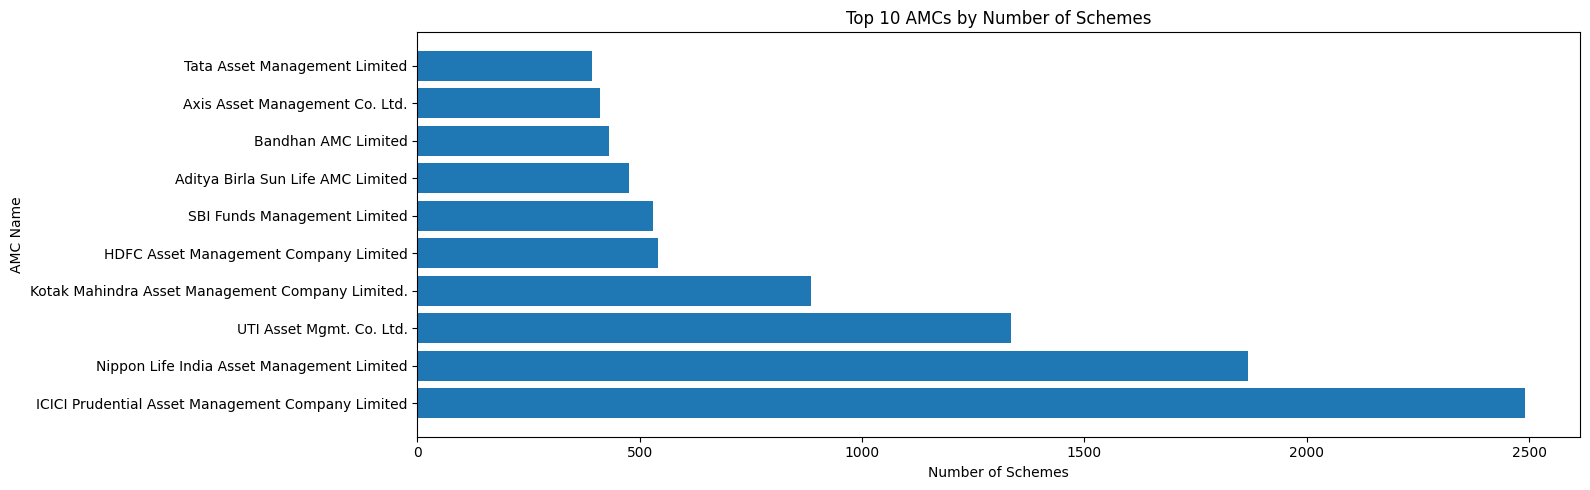

In [ ]:
plt.figure(figsize=(16, 5))
plt.barh(top_amc.index, top_amc.values)
plt.title("Top 10 AMCs by Number of Schemes")
plt.xlabel("Number of Schemes")
plt.ylabel("AMC Name")
plt.tight_layout()
plt.show()


**Insight:** ICICI Prudential Asset Management leads with the highest number of schemes, indicating a dominant product portfolio strategy among all 51 AMCs.


## Analysis 3 — NAV Distribution

Understanding the spread of Net Asset Values across all fund schemes. NAV is filtered below 500 to avoid skew from outliers.


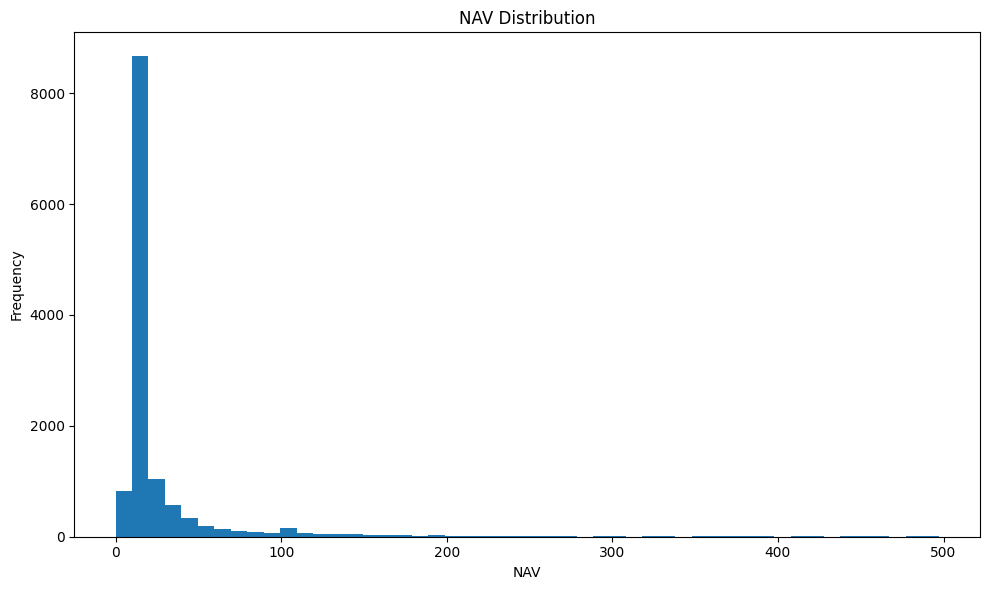

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df[df['NAV'] < 500]['NAV'], bins=50)
plt.title("NAV Distribution")
plt.xlabel("NAV")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Insight:** Most funds have NAV under ₹100, meaning the majority are relatively young or recently launched. High NAV funds are older schemes that have compounded over time.


## Analysis 4 — Top 10 AMCs by Average NAV

Checking which AMCs have the highest average NAV across their schemes.


In [ ]:
highest_avg_NAV = df.groupby('AMC')['NAV'].mean().sort_values(ascending=False).head(10)
highest_avg_NAV


,NAV
AMC,
IL&FS Infra Asset Management Limited,1.755853e+06
Invesco Asset Management (India) Private Limited,9.382787e+02
Trust Asset Management Private Limited,8.508289e+02
Shriram Asset Management Co. Ltd.,3.955969e+02
Franklin Templeton Asset Management (India) Private Limited,3.910078e+02
Bajaj Finserv Asset Management Limited,3.885120e+02
Jio BlackRock Asset Management Private Limited,3.778914e+02
ITI Asset Management Limited,3.739660e+02
Canara Robeco Asset Management Company Limited,3.606141e+02


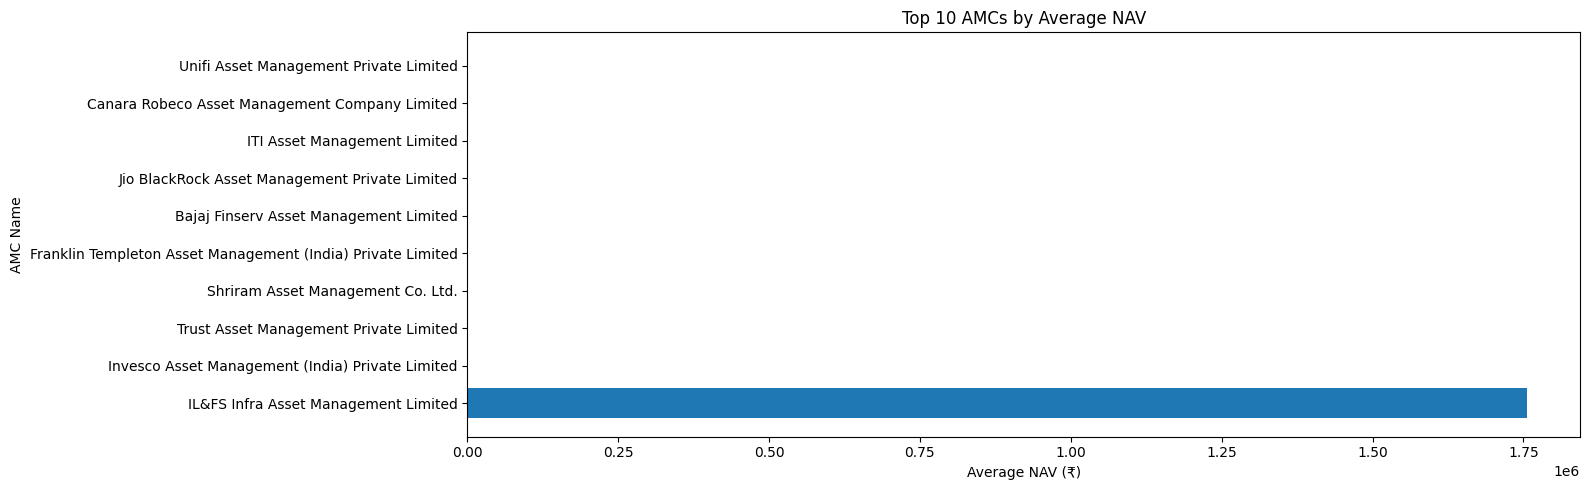

In [ ]:
plt.figure(figsize=(16, 5))
plt.barh(highest_avg_NAV.index, highest_avg_NAV.values)
plt.title("Top 10 AMCs by Average NAV")
plt.xlabel("Average NAV (₹)")
plt.ylabel("AMC Name")
plt.tight_layout()
plt.show()


**Insight:** IL&FS Infra Asset Management has the highest average NAV despite not being in the top 10 by scheme count — showing that more schemes does not always mean better fund performance.


## Analysis 5 — Category Wise Average NAV

Finding which fund categories have the highest average NAV.


In [ ]:
avg_nav_by_category = df.groupby('Scheme_Category')['NAV'].mean().sort_values(ascending=False).head(10)
avg_nav_by_category


,NAV
Scheme_Category,
Income,4563.929484
Debt Scheme - Liquid Fund,1169.906481
Debt Scheme - Overnight Fund,1150.197459
Debt Scheme - Low Duration Fund,949.847062
Debt Scheme - Money Market Fund,868.541890
Debt Scheme - Ultra Short Duration Fund,766.213630
Debt Scheme - Short Duration Fund,485.398415
Debt Scheme - Floater Fund,330.522301
Equity Scheme - Mid Cap Fund,257.357363


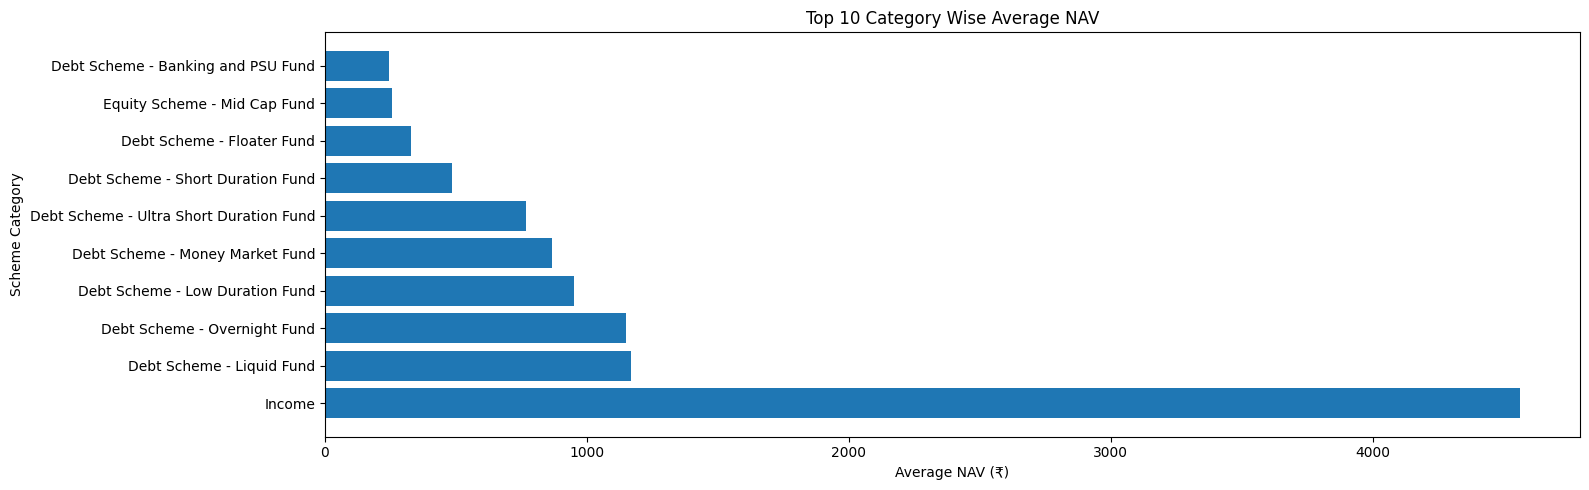

In [ ]:
plt.figure(figsize=(16, 5))
plt.barh(avg_nav_by_category.index, avg_nav_by_category.values)
plt.title("Top 10 Category Wise Average NAV")
plt.xlabel("Average NAV (₹)")
plt.ylabel("Scheme Category")
plt.tight_layout()
plt.show()


**Insight:** Debt Scheme - Liquid Funds have the highest average NAV, reflecting their long history and stable compounding nature. They are preferred for short-term investments due to low volatility.


## Analysis 6 — Fund Launches Over Years

Tracking how many mutual fund schemes were launched each year to understand industry growth trends.


In [ ]:
df['Launch_Year'] = pd.to_datetime(df['Launch_Date']).dt.year
Launch_Year = df['Launch_Year'].value_counts().sort_index()
Launch_Year


,count
Launch_Year,
1900,17
1988,6
1989,36
1991,4
1992,8
1993,42
1994,49
1995,66
1996,24


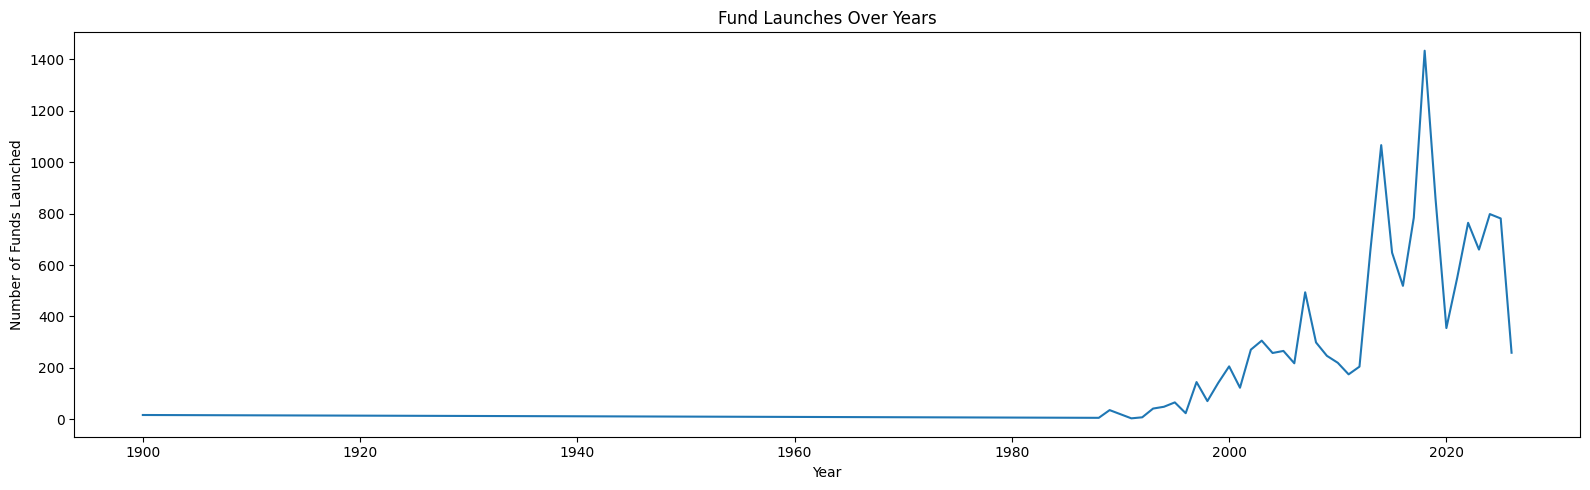

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(Launch_Year.index, Launch_Year.values)
plt.title("Fund Launches Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Funds Launched")
plt.tight_layout()
plt.show()


**Insight:** Fund launches peaked in 2018 with 1,433 new schemes, driven by SEBI recategorisation and a strong bull market. A clear dip is visible during COVID-19 (2020). Post-COVID shows a gradual recovery pattern.


## Analysis 7 — Minimum Investment Distribution

Analysing the minimum investment amounts to understand fund accessibility for retail investors.


In [ ]:
min_inv_dis = df['Scheme_Min_Amt'].value_counts().sort_index().head(10)
min_inv_dis


,count
Scheme_Min_Amt,
1.0,1
3.0,9
5.0,15
10.0,28
100.0,315
300.0,4
500.0,366
1000.0,391
1500.0,2


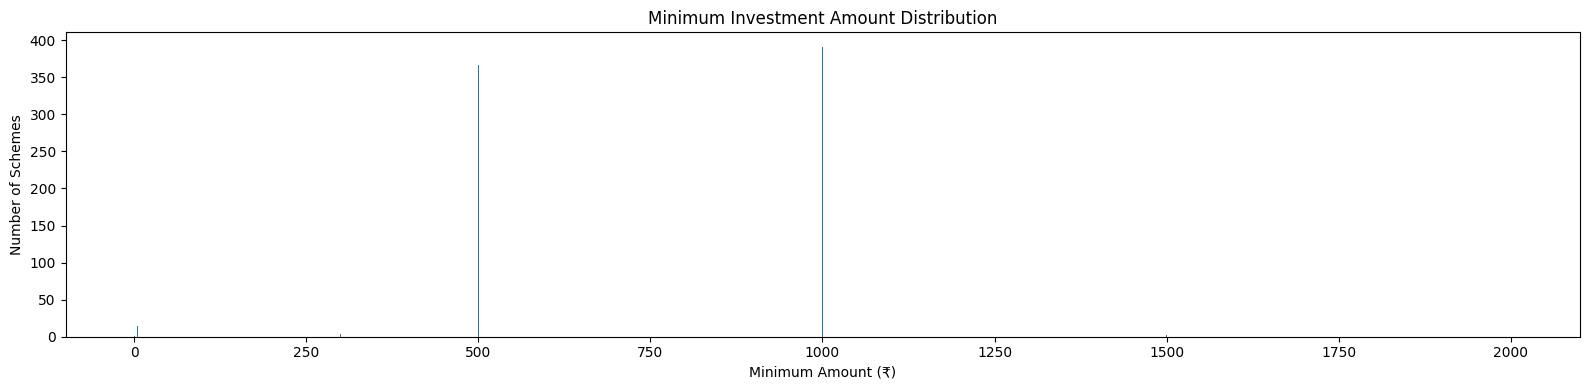

In [ ]:
plt.figure(figsize=(16, 4))
plt.bar(min_inv_dis.index, min_inv_dis.values)
plt.title("Minimum Investment Amount Distribution")
plt.xlabel("Minimum Amount (₹)")
plt.ylabel("Number of Schemes")
plt.tight_layout()
plt.show()


**Insight:** ₹1,000 is the most common minimum investment amount, reflecting the industry's focus on retail investor accessibility and financial inclusion.


## Summary

| Analysis | Finding |
|---|---|
| Scheme Type | Open Ended dominates at 66% |
| Top AMCs by Schemes | ICICI Prudential leads |
| NAV Distribution | Most funds under ₹100 NAV |
| Top AMCs by Avg NAV | IL&FS Infra tops — more schemes ≠ higher NAV |
| Category Wise NAV | Liquid Funds have highest average NAV |
| Fund Launches | Peak in 2018, COVID dip in 2020 |
| Min Investment | ₹1,000 is most common entry point |
